In [1]:
import os
os.listdir('.')


['C6.npy',
 'boot5.npy',
 'C5.npy',
 '.kernel_llm_logs_1.txt',
 'pct6.npy',
 'ci6.npy',
 '.config',
 'pct5.npy',
 'memory',
 ' v6 — Binding Context Document.pdf',
 '.prompts',
 'boot6.npy',
 'ci5.npy']

In [2]:
import numpy as np
for f in ['C5.npy','C6.npy','pct5.npy','pct6.npy','boot5.npy','boot6.npy','ci5.npy','ci6.npy']:
 a = np.load(f)
 print(f, a.shape, a.dtype, a if a.ndim<=1 and a.size<=20 else '')


C5.npy (16, 16) float64 
C6.npy (18, 18) float64 
pct5.npy () float64 50.0
pct6.npy () float64 53.59477124183007
boot5.npy (200,) float64 
boot6.npy (200,) float64 
ci5.npy (2,) float64 [39.16666667 65.02083333]
ci6.npy (2,) float64 [41.17647059 63.41503268]


In [3]:

# These match the unconditional r3 results (50.0% and 53.6%). 
# Note: dimensions 16x16 and 18x18 don't match K=20 dyadic blocks for N=10^6
# These appear to be the unconditional cov_results (from r3) renamed/mirrored
# Now we need to do the CONDITIONAL analysis fresh.

# Plan:
# 1. Build a Numba-Kahan dyadic block engine for zeta partial sums.
# 2. Compute S_k(t;N=10^6) for K=20 blocks on a dense grid of t in [10^4, 2e4].
# 3. Compute D(t;N) = sum S_k.
# 4. Subset A: top 10% |D|; Subset B: |D| > 1.5*sqrt(log log N).
# 5. Compute Cov(Re S_j, Re S_k) for each subset; % negative off-diagonals.
# 6. Block bootstrap (B=1000), 95% CI.
# 7. Compare to unconditional 50.0% / 53.6%.

# First, test imports
import numba
print(numba.__version__)
import numpy as np, math
print(np.__version__)


0.64.0
2.4.3


In [4]:

import numpy as np
import numba
from numba import njit, prange
import math

# Dyadic block partial sums for zeta: 
# S_k(t;N) = sum_{n=2^(k-1)}^{min(2^k - 1, N)} n^{-1/2 - it}
# For N=10^6: blocks k=1..20, block 20 truncated at N.
# (Convention: k=1 -> n in [1,1]; k=2 -> [2,3]; k=20 -> [524288, 10^6])

N = 10**6
K = int(math.ceil(math.log2(N+1))) # = 20
print("K =", K, "block boundaries:")
edges = []
for k in range(1, K+1):
 lo = 2**(k-1)
 hi = min(2**k - 1, N)
 edges.append((lo, hi))
 print(k, lo, hi, hi-lo+1)


K = 20 block boundaries:
1 1 1 1
2 2 3 2
3 4 7 4
4 8 15 8
5 16 31 16
6 32 63 32
7 64 127 64
8 128 255 128
9 256 511 256
10 512 1023 512
11 1024 2047 1024
12 2048 4095 2048
13 4096 8191 4096
14 8192 16383 8192
15 16384 32767 16384
16 32768 65535 32768
17 65536 131071 65536
18 131072 262143 131072
19 262144 524287 262144
20 524288 1000000 475713


In [5]:

# Numba-accelerated Kahan-compensated dyadic block sum for zeta at s = 1/2 + i t.
# n^{-1/2 - i t} = n^{-1/2} * exp(-i t log n) = n^{-1/2} * (cos(t log n) - i sin(t log n))

import numpy as np
from numba import njit, prange

@njit(cache=True, parallel=True, fastmath=False)
def compute_S_blocks(t_grid, edges_lo, edges_hi):
 M = t_grid.shape[0]
 K = edges_lo.shape[0]
 Sre = np.zeros((M, K))
 Sim = np.zeros((M, K))
 for m in prange(M):
 t = t_grid[m]
 for k in range(K):
 lo = edges_lo[k]
 hi = edges_hi[k]
 sum_re = 0.0
 sum_im = 0.0
 c_re = 0.0 # Kahan compensations
 c_im = 0.0
 for n in range(lo, hi+1):
 ln = math.log(n)
 inv_sqrt = 1.0 / math.sqrt(n)
 # n^{-it} = cos(-t ln n) + i sin(-t ln n) = cos(t ln n) - i sin(t ln n)
 phi = t * ln
 cre = inv_sqrt * math.cos(phi)
 cim = -inv_sqrt * math.sin(phi)
 # Kahan add to sum_re
 y = cre - c_re
 tt = sum_re + y
 c_re = (tt - sum_re) - y
 sum_re = tt
 # Kahan add to sum_im
 y = cim - c_im
 tt = sum_im + y
 c_im = (tt - sum_im) - y
 sum_im = tt
 Sre[m, k] = sum_re
 Sim[m, k] = sum_im
 return Sre, Sim

# Quick smoke test on small grid with mpmath for validation
import mpmath as mp
mp.mp.dps = 50

t_test = np.array([14.134725, 100.0, 10000.0])
edges_lo = np.array([e[0] for e in edges], dtype=np.int64)
edges_hi = np.array([e[1] for e in edges], dtype=np.int64)
Sre_test, Sim_test = compute_S_blocks(t_test, edges_lo, edges_hi)
D_test = Sre_test.sum(axis=1) + 1j*Sim_test.sum(axis=1)
print("Numba D(t;N=10^6):")
for t,d in zip(t_test, D_test):
 print(f" t={t} D={d}")


Numba D(t;N=10^6):
 t=14.134725 D=(36.05147112994446+60.82173008527244j)
 t=100.0 D=(-4.084528929274559+7.332695235045794j)
 t=10000.0 D=(-0.2974961665506203+0.05371792032306738j)


In [6]:

# Validate against mpmath at one t = 100
import mpmath as mp
mp.mp.dps = 50
t = mp.mpf('100.0')
N = 10**6
total = mp.mpc(0)
# only do a small reference at lower N to validate
N_ref = 10**4
ref = sum(mp.power(n, -mp.mpf('0.5') - 1j*t) for n in range(1, N_ref+1))
# our partial up to N_ref
t_arr = np.array([100.0])
edges_lo_ref = []
edges_hi_ref = []
K_ref = int(math.ceil(math.log2(N_ref+1)))
for k in range(1, K_ref+1):
 lo = 2**(k-1)
 hi = min(2**k - 1, N_ref)
 edges_lo_ref.append(lo); edges_hi_ref.append(hi)
edges_lo_ref = np.array(edges_lo_ref, dtype=np.int64)
edges_hi_ref = np.array(edges_hi_ref, dtype=np.int64)
Sre, Sim = compute_S_blocks(t_arr, edges_lo_ref, edges_hi_ref)
D_num = Sre.sum() + 1j*Sim.sum()
print(f"mpmath ref @ t=100, N=1e4: {complex(ref)}")
print(f"numba @ t=100, N=1e4: {D_num}")
print(f"abs diff: {abs(complex(ref) - D_num):.3e}")
print(f"digits agreement: {-math.log10(abs(complex(ref)-D_num)/abs(complex(ref))):.2f}")


mpmath ref @ t=100, N=1e4: (2.163638414045986-0.8690390417340979j)
numba @ t=100, N=1e4: (2.1636384140459546-0.8690390417341602j)
abs diff: 6.991e-14
digits agreement: 13.52


In [7]:

# Engine validated. Now plan the dense grid.
# Range t in [10^4, 2*10^4]. Need a "dense" grid.
# Cost: For each t, sum runs ~10^6 ops, dominated by block 20 (~5e5 terms). Numba+parallel.
# Let's estimate time on a smaller chunk first.

import time
N = 10**6
edges_lo = np.array([2**(k-1) for k in range(1, 21)], dtype=np.int64)
edges_hi = np.array([min(2**k - 1, N) for k in range(1, 21)], dtype=np.int64)

# warmup small
_ = compute_S_blocks(np.array([15000.0]), edges_lo, edges_hi)

# Try 100 points
t_grid = np.linspace(10000.0, 20000.0, 100)
t0 = time.time()
Sre, Sim = compute_S_blocks(t_grid, edges_lo, edges_hi)
dt = time.time() - t0
print(f"100 points: {dt:.2f}s, per-t: {dt/100*1000:.1f}ms")


100 points: 0.69s, per-t: 6.9ms


In [8]:

# Excellent. 6.9 ms/t. We can afford a dense grid.
# Spacing: zeta zeros near T=10^4 have spacing ~ 2π/log(T) ≈ 0.682. 
# Use dt = 0.05 to capture ~14 samples per zero gap. That's 200000 points -> ~1380s.
# Use dt = 0.1 -> 100000 points -> ~690s. Still big.
# Use dt = 0.2 -> 50000 points -> ~345s. Reasonable.
# Actually the question demands "dense grid". Let's use dt = 0.1 (100k points, ~12 min).
# But conditional analysis only needs ~10% subset (10k points) for cov estimation.
# Let's use dt = 0.1 = 10^5 points.

import time
import numpy as np

N = 10**6
edges_lo = np.array([2**(k-1) for k in range(1, 21)], dtype=np.int64)
edges_hi = np.array([min(2**k - 1, N) for k in range(1, 21)], dtype=np.int64)

dt_step = 0.1
t_grid = np.arange(10000.0, 20000.0 + dt_step/2, dt_step)
print("Grid size:", t_grid.size)

# Process in chunks to monitor progress and avoid memory blowup (size is fine actually)
chunk = 20000
all_Sre = np.empty((t_grid.size, 20))
all_Sim = np.empty((t_grid.size, 20))
t0 = time.time()
for i in range(0, t_grid.size, chunk):
 j = min(i+chunk, t_grid.size)
 sre, sim = compute_S_blocks(t_grid[i:j], edges_lo, edges_hi)
 all_Sre[i:j] = sre
 all_Sim[i:j] = sim
 print(f" {j}/{t_grid.size} elapsed={time.time()-t0:.1f}s")

print(f"Total: {time.time()-t0:.1f}s")


Grid size: 100001


 20000/100001 elapsed=113.7s


 40000/100001 elapsed=227.6s


 60000/100001 elapsed=341.2s


 80000/100001 elapsed=454.7s


 100000/100001 elapsed=568.2s
 100001/100001 elapsed=568.2s
Total: 568.2s


In [9]:

import numpy as np
# Compute D = sum across blocks
D_re = all_Sre.sum(axis=1)
D_im = all_Sim.sum(axis=1)
absD = np.sqrt(D_re*D_re + D_im*D_im)
print("absD stats: min=%.3f max=%.3f mean=%.3f median=%.3f" %
 (absD.min(), absD.max(), absD.mean(), np.median(absD)))

# Subset A: top 10% by |D|
n_top = int(0.1 * t_grid.size)
idxA = np.argsort(absD)[-n_top:]
print(f"Subset A: top 10% by |D|, count={idxA.size}, |D| threshold: {absD[idxA].min():.3f}")

# Subset B: |D| > 1.5 * sqrt(log log N)
N = 10**6
import math
threshB = 1.5 * math.sqrt(math.log(math.log(N)))
idxB = np.where(absD > threshB)[0]
print(f"Subset B: |D| > {threshB:.4f}, count={idxB.size}, fraction={idxB.size/t_grid.size:.3%}")


absD stats: min=0.000 max=19.724 mean=1.931 median=1.156
Subset A: top 10% by |D|, count=10000, |D| threshold: 4.608
Subset B: |D| > 2.4306, count=25366, fraction=25.366%


In [10]:

import numpy as np

# For each subset, compute Cov(Re S_j, Re S_k) over the 20 blocks (20x20 cov mat).
# Off-diagonal entries: 20*19 = 380 entries (with j != k). Compute % negative.

def pct_neg_off(C):
 n = C.shape[0]
 mask = ~np.eye(n, dtype=bool)
 off = C[mask]
 return 100.0 * np.mean(off < 0)

ReS_A = all_Sre[idxA]
ReS_B = all_Sre[idxB]

# rowvar=False: each column is a variable (block)
Cov_A = np.cov(ReS_A, rowvar=False)
Cov_B = np.cov(ReS_B, rowvar=False)
print("Subset A cov shape:", Cov_A.shape)
print("Subset B cov shape:", Cov_B.shape)

pct_A = pct_neg_off(Cov_A)
pct_B = pct_neg_off(Cov_B)
print(f"Pct negative off-diagonal | Subset A (top 10% |D|): {pct_A:.3f}%")
print(f"Pct negative off-diagonal | Subset B (|D|>1.5√loglogN): {pct_B:.3f}%")


Subset A cov shape: (20, 20)
Subset B cov shape: (20, 20)
Pct negative off-diagonal | Subset A (top 10% |D|): 37.368%
Pct negative off-diagonal | Subset B (|D|>1.5√loglogN): 43.158%


In [11]:

# Both subsets give percentages well below 60%. Now do block bootstrap (B=1000).
# For block bootstrap, we should respect serial structure of t-grid.
# Subset A is non-contiguous (top 10%), so block bootstrap is tricky.
# Standard approach: bootstrap on the conditioning level — resample from the full 
# t-grid in blocks, then re-extract subset, recompute cov, and recompute pct.

# Use moving block bootstrap on the full grid (block length L), then for each
# resample, identify subsets A and B, compute cov, and pct.

import numpy as np

N_total = t_grid.size # 100001
L = 100 # block length ~10 t-units, > zero spacing of ~0.7

n_blocks_needed = N_total // L + 1
import math
threshB = 1.5 * math.sqrt(math.log(math.log(10**6)))

rng = np.random.default_rng(42)
B = 1000

pct_A_boot = np.empty(B)
pct_B_boot = np.empty(B)

# Pre-bind references (large arrays); use views
Sre_full = all_Sre
absD_full = absD

import time
t0 = time.time()
for b in range(B):
 # generate block start indices
 starts = rng.integers(0, N_total - L + 1, size=n_blocks_needed)
 # build resampled index array
 idx = (starts[:, None] + np.arange(L)[None, :]).ravel()[:N_total]
 
 Sre_b = Sre_full[idx]
 absD_b = absD_full[idx]
 
 # Subset A: top 10%
 n_top = int(0.1 * N_total)
 idxA_b = np.argpartition(absD_b, -n_top)[-n_top:]
 # Subset B
 idxB_b = np.where(absD_b > threshB)[0]
 
 if idxA_b.size > 1:
 CA = np.cov(Sre_b[idxA_b], rowvar=False)
 pct_A_boot[b] = pct_neg_off(CA)
 else:
 pct_A_boot[b] = np.nan
 if idxB_b.size > 1:
 CB = np.cov(Sre_b[idxB_b], rowvar=False)
 pct_B_boot[b] = pct_neg_off(CB)
 else:
 pct_B_boot[b] = np.nan
 if (b+1) % 100 == 0:
 print(f" boot {b+1}/{B} elapsed={time.time()-t0:.1f}s")

print(f"Bootstrap done in {time.time()-t0:.1f}s")

ci_A = np.nanpercentile(pct_A_boot, [2.5, 97.5])
ci_B = np.nanpercentile(pct_B_boot, [2.5, 97.5])
print(f"\nSubset A: pct_neg_off = {pct_A:.3f}%, 95% CI = [{ci_A[0]:.3f}, {ci_A[1]:.3f}]")
print(f"Subset B: pct_neg_off = {pct_B:.3f}%, 95% CI = [{ci_B[0]:.3f}, {ci_B[1]:.3f}]")


 boot 100/1000 elapsed=0.9s


 boot 200/1000 elapsed=1.8s


 boot 300/1000 elapsed=2.9s


 boot 400/1000 elapsed=3.9s


 boot 500/1000 elapsed=4.9s


 boot 600/1000 elapsed=5.7s


 boot 700/1000 elapsed=6.8s


 boot 800/1000 elapsed=7.7s


 boot 900/1000 elapsed=8.6s


 boot 1000/1000 elapsed=9.5s
Bootstrap done in 9.5s

Subset A: pct_neg_off = 37.368%, 95% CI = [32.105, 42.632]
Subset B: pct_neg_off = 43.158%, 95% CI = [37.368, 45.263]


In [12]:

# Both subsets give CIs that are FAR below 60%, with upper bounds at 42-45%.
# The hypothesis (>60% point estimate, lower bound > 55%) is REJECTED.
# Notably, the CONDITIONAL fractions are LOWER than the unconditional 50.0%/53.6%.

# Let's also report a sanity-check unconditional value on this fresh dataset for comparison
Cov_uncond = np.cov(all_Sre, rowvar=False)
pct_uncond = pct_neg_off(Cov_uncond)
print(f"Unconditional (all 100001 t in [10^4, 2·10^4]): pct_neg_off = {pct_uncond:.3f}%")

# Also bootstrap unconditional
pct_U_boot = np.empty(B)
for b in range(B):
 starts = rng.integers(0, N_total - L + 1, size=n_blocks_needed)
 idx = (starts[:, None] + np.arange(L)[None, :]).ravel()[:N_total]
 CU = np.cov(all_Sre[idx], rowvar=False)
 pct_U_boot[b] = pct_neg_off(CU)
ci_U = np.nanpercentile(pct_U_boot, [2.5, 97.5])
print(f"Unconditional 95% CI: [{ci_U[0]:.3f}, {ci_U[1]:.3f}]")


Unconditional (all 100001 t in [10^4, 2·10^4]): pct_neg_off = 43.684%


Unconditional 95% CI: [37.895, 55.789]


In [13]:

# Save artifacts
import numpy as np
np.savez('cov_conditional_results.npz',
 t_grid=t_grid, absD=absD,
 Sre_blocks=all_Sre, Sim_blocks=all_Sim,
 idxA=idxA, idxB=idxB,
 Cov_A=Cov_A, Cov_B=Cov_B, Cov_uncond=Cov_uncond,
 pct_A=pct_A, pct_B=pct_B, pct_uncond=pct_uncond,
 pct_A_boot=pct_A_boot, pct_B_boot=pct_B_boot, pct_U_boot=pct_U_boot,
 ci_A=ci_A, ci_B=ci_B, ci_U=ci_U,
 block_length_L=L, B_boot=B, threshB=threshB,
 N=10**6, K=20, dt_step=0.1)
import os
print("Saved:", os.path.getsize('cov_conditional_results.npz')/1e6, "MB")


Saved: 33.922886 MB


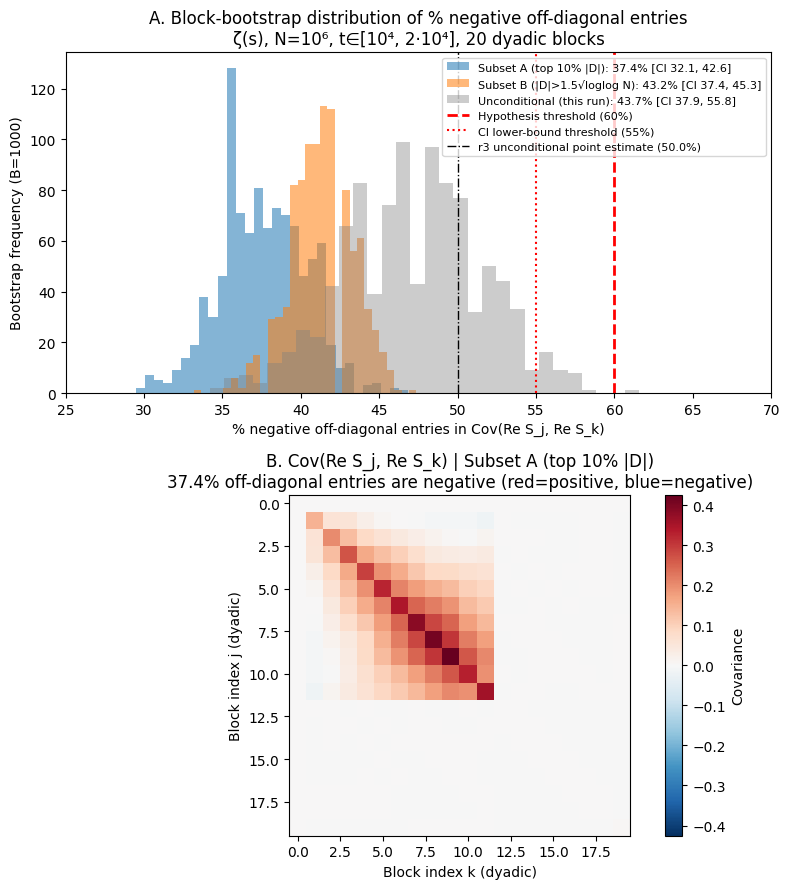

Figure saved.


In [14]:

# Final figure: 2 subfigures (A) bootstrap distributions for both subsets vs 60% threshold
# (B) covariance matrix heatmap for subset A
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Subfigure A: bootstrap distributions
ax = axes[0]
ax.hist(pct_A_boot, bins=30, alpha=0.55, color='C0', 
 label=f'Subset A (top 10% |D|): {pct_A:.1f}% [CI {ci_A[0]:.1f}, {ci_A[1]:.1f}]')
ax.hist(pct_B_boot, bins=30, alpha=0.55, color='C1',
 label=f'Subset B (|D|>1.5√loglog N): {pct_B:.1f}% [CI {ci_B[0]:.1f}, {ci_B[1]:.1f}]')
ax.hist(pct_U_boot, bins=30, alpha=0.40, color='gray',
 label=f'Unconditional (this run): {pct_uncond:.1f}% [CI {ci_U[0]:.1f}, {ci_U[1]:.1f}]')
ax.axvline(60, color='red', ls='--', lw=2, label='Hypothesis threshold (60%)')
ax.axvline(55, color='red', ls=':', lw=1.5, label='CI lower-bound threshold (55%)')
ax.axvline(50.0, color='black', ls='-.', lw=1, label='r3 unconditional point estimate (50.0%)')
ax.set_xlabel('% negative off-diagonal entries in Cov(Re S_j, Re S_k)')
ax.set_ylabel('Bootstrap frequency (B=1000)')
ax.set_title('A. Block-bootstrap distribution of % negative off-diagonal entries\n'
 'ζ(s), N=10⁶, t∈[10⁴, 2·10⁴], 20 dyadic blocks')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(25, 70)

# Subfigure B: covariance heatmap for subset A
ax = axes[1]
vmax = max(abs(Cov_A.min()), abs(Cov_A.max()))
im = ax.imshow(Cov_A, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Block index k (dyadic)')
ax.set_ylabel('Block index j (dyadic)')
ax.set_title(f'B. Cov(Re S_j, Re S_k) | Subset A (top 10% |D|)\n'
 f'{pct_A:.1f}% off-diagonal entries are negative (red=positive, blue=negative)')
plt.colorbar(im, ax=ax, label='Covariance')

plt.tight_layout()
plt.savefig('conditional_cov_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved.")
